# Lecturue des fichiers

In [77]:
from pathlib import Path
import pandas as pd

# Lister tous les fichiers Parquet dans le dossier data/duck_db
parquet_dir = Path('../data/duck_db')
parquet_files = sorted(parquet_dir.glob('*.parquet'))


In [78]:
import duckdb

# Connexion à une base DuckDB (fichier ou en mémoire)
con = duckdb.connect(database=':memory:')  # ou 'ma_base.duckdb' pour un fichier persistant


## Nombre total d'entré

In [79]:
# Afficher le nombre total de lignes dans tous les fichiers Parquet via DuckDB
if parquet_files:
    total_rows_duckdb = con.execute(
        "SELECT SUM(row_count) FROM (" +
        " UNION ALL ".join(
            [f"SELECT COUNT(*) AS row_count FROM parquet_scan('{str(f)}')" for f in parquet_files]
        ) +
        ")"
    ).fetchone()[0]
    print(f"Nombre total de lignes dans les fichiers Parquet (via DuckDB) : {total_rows_duckdb}")
else:
    print("Aucun fichier Parquet trouvé.")

Nombre total de lignes dans les fichiers Parquet (via DuckDB) : 109950743


## Lecture de tout les fichiers

In [80]:
# Lire et concaténer toutes les données Parquet du dossier duck_db via DuckDB
# Ajout d'un paramètre pour définir dynamiquement la limite
limit = 10000  # Modifiez cette valeur selon vos besoins

if parquet_files:
    query = " UNION ALL ".join([f"SELECT * FROM parquet_scan('{str(f)}')" for f in parquet_files])
    if limit is not None:
        query = f"SELECT * FROM ({query}) LIMIT {limit}"
    df_all = con.execute(query).df()
    print(f"Nombre total de lignes lues : {len(df_all)}")
    display(df_all.head())
else:
    print("Aucun fichier Parquet trouvé dans le dossier duck_db.")

Nombre total de lignes lues : 10000


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,None,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


In [81]:
df_all.shape

(10000, 9)

## Lecture du premier fichier

In [82]:

# Exemple : lire le même fichier Parquet que précédemment via DuckDB
if parquet_files:
    parquet_path = str(parquet_files[0])
    print(f"Lecture via DuckDB : {parquet_path}")
    df_duck = con.execute(f"SELECT * FROM parquet_scan('{parquet_path}') LIMIT 10000").df()
    display(df_duck.head(2000))
else:
    print("Aucun fichier Parquet à lire avec DuckDB.")

Lecture via DuckDB : ..\data\duck_db\2019-Nov.parquet


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,None,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2
...,...,...,...,...,...,...,...,...,...
1995,2019-11-01 00:13:30 UTC,view,53300014,2141355068383822734,None,perilla,51.46,515474976,222c370b-0fac-4287-982b-e340f5eaf3a1
1996,2019-11-01 00:13:30 UTC,view,1004158,2053013555631882655,electronics.smartphone,samsung,733.61,560865203,a2dfee28-0b19-49aa-a589-15ec39793443
1997,2019-11-01 00:13:30 UTC,view,47000085,2110937189394154243,None,nikon,197.95,561293561,5d339491-4493-4b6a-8d27-f0eecbd265c7
1998,2019-11-01 00:13:30 UTC,view,26200591,2053013563693335403,None,None,203.35,513572498,77ac0d41-222f-4248-a3bf-d159144c87d6


In [83]:
# Afficher le nombre total de lignes du fichier Parquet sans LIMIT
if parquet_files:
    parquet_path = str(parquet_files[0])
    total_rows_full = con.execute(f"SELECT COUNT(*) FROM parquet_scan('{parquet_path}')").fetchone()[0]
    print(f"Nombre total de lignes dans le fichier Parquet sans LIMIT : {total_rows_full}")
else:
    print("Aucun fichier Parquet trouvé.")

Nombre total de lignes dans le fichier Parquet sans LIMIT : 67501979


In [84]:
# Copier le résultat DuckDB dans un DataFrame pandas nommé df
if 'df_all' in locals():
    df = df_all.copy()
    print("Le DataFrame df est prêt pour l'analyse.")
    df    
else:
    print("Aucun résultat DuckDB à copier dans df.")

df


Le DataFrame df est prêt pour l'analyse.


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,None,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2
...,...,...,...,...,...,...,...,...,...
9995,2019-11-01 00:56:00 UTC,view,15100145,2053013557024391671,None,lider,345.93,528293100,f6da70f4-0597-47c0-a49e-f92601d2653a
9996,2019-11-01 00:56:00 UTC,view,3600545,2053013563810775923,appliances.kitchen.washer,samsung,579.14,566205335,a426ed82-316b-4eb3-b744-a69ef2cb0121
9997,2019-11-01 00:56:00 UTC,view,1004767,2053013555631882655,electronics.smartphone,samsung,242.63,566286942,5b6eec5e-24e2-49f6-b57e-a7ff28fa4842
9998,2019-11-01 00:56:00 UTC,view,17200399,2053013559792632471,furniture.living_room.sofa,None,507.07,512797937,39b19a6e-6acf-4ba9-8c86-5d8a8ba2f980


In [85]:
import hashlib
print(df.columns.tolist())

def hash_value(val):
    return hashlib.sha256(str(val).encode()).hexdigest()

# Pseudonymiser les colonnes sensibles
df['user_id_pseudo'] = df['user_id'].apply(hash_value)
df['user_session_pseudo'] = df['user_session'].apply(hash_value)

# (Optionnel) Supprimer les colonnes originales
df = df.drop(['user_id', 'user_session'], axis=1)
print(df.columns.tolist())
df


['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id_pseudo', 'user_session_pseudo']


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id_pseudo,user_session_pseudo
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,307a2430088ca6da23ea7ba788fa4637070cf56ad6e3fe...,6b03bdce14b9f905900510fe1d08df11b7663216217a5b...
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,29b31d55c81bbf870af43b4baf5b932cd1bdf240f35647...,ae202c0a11b2f3e6abdd2df7e3b547a8e5634cce0d6f14...
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,None,creed,28.31,9f0e60b716f203f881a4015d6aa19866625c41298323b6...,d28c4192eb553c229638528bc50d3843399f3392259abe...
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,d5f7057379e143ec2df9db60ed676ed0a107e49adc2406...,cea392923495ed4f1015dcc6642bbb2d5559ddac148589...
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,098355b4d8e357010c449c2c6d5292baf9a05b1915cdaf...,6ce01f1be7fdd1191a1b76a19a83c6b8b08c206de8c052...
...,...,...,...,...,...,...,...,...,...
9995,2019-11-01 00:56:00 UTC,view,15100145,2053013557024391671,None,lider,345.93,c7eed9413d7b7ad5fdc6002657c3e73ee3c5f42b2d16f5...,1354602991e9fa0c9edb72aa4e41787ed047e62cf8bb56...
9996,2019-11-01 00:56:00 UTC,view,3600545,2053013563810775923,appliances.kitchen.washer,samsung,579.14,641d197e7124093df05a9d9707cf530f92054827a4e868...,ee84668879727666e895ebd417c023ae78e87463f7db00...
9997,2019-11-01 00:56:00 UTC,view,1004767,2053013555631882655,electronics.smartphone,samsung,242.63,2ddc4cf37247844ed5add45063724361626d51ea632293...,ed7bf843b8bad7cdefc87fae61aa60510f6a35c980151f...
9998,2019-11-01 00:56:00 UTC,view,17200399,2053013559792632471,furniture.living_room.sofa,None,507.07,24702fcfdae0bf629bba70280b695dff59ff05dca22132...,5239cf652b99c2cead480da598e26e4743273fca358e85...


In [86]:
# Comprendre la structure des données
print("Aperçu du DataFrame :")
display(df.head())

print("\nTypes de colonnes :")
print(df.dtypes)

print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

print("\nNombre de doublons :")
print(df.duplicated().sum())


Aperçu du DataFrame :


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id_pseudo,user_session_pseudo
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,307a2430088ca6da23ea7ba788fa4637070cf56ad6e3fe...,6b03bdce14b9f905900510fe1d08df11b7663216217a5b...
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,29b31d55c81bbf870af43b4baf5b932cd1bdf240f35647...,ae202c0a11b2f3e6abdd2df7e3b547a8e5634cce0d6f14...
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,None,creed,28.31,9f0e60b716f203f881a4015d6aa19866625c41298323b6...,d28c4192eb553c229638528bc50d3843399f3392259abe...
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,d5f7057379e143ec2df9db60ed676ed0a107e49adc2406...,cea392923495ed4f1015dcc6642bbb2d5559ddac148589...
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,098355b4d8e357010c449c2c6d5292baf9a05b1915cdaf...,6ce01f1be7fdd1191a1b76a19a83c6b8b08c206de8c052...



Types de colonnes :
event_time              object
event_type              object
product_id               int64
category_id              int64
category_code           object
brand                   object
price                  float64
user_id_pseudo          object
user_session_pseudo     object
dtype: object

Valeurs manquantes par colonne :
event_time                0
event_type                0
product_id                0
category_id               0
category_code          3741
brand                  1805
price                     0
user_id_pseudo            0
user_session_pseudo       0
dtype: int64

Nombre de doublons :
0


In [87]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   event_time           10000 non-null  object 
 1   event_type           10000 non-null  object 
 2   product_id           10000 non-null  int64  
 3   category_id          10000 non-null  int64  
 4   category_code        6259 non-null   object 
 5   brand                8195 non-null   object 
 6   price                10000 non-null  float64
 7   user_id_pseudo       10000 non-null  object 
 8   user_session_pseudo  10000 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 703.3+ KB


# Visualisation des valeurs manquante

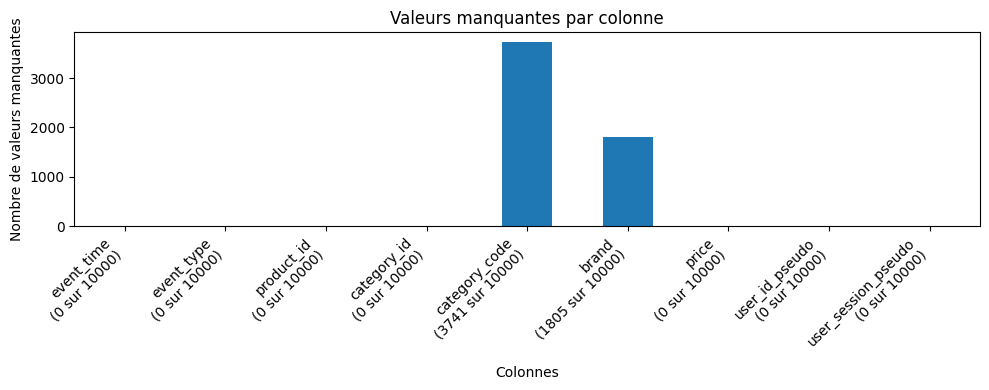

In [88]:
import matplotlib.pyplot as plt

total_rows = len(df)
missing_values = df.isnull().sum()
labels = [f"{col}\n({missing} sur {total_rows})" for col, missing in missing_values.items()]

ax = missing_values.plot(kind='bar', figsize=(10, 4))
ax.set_title('Valeurs manquantes par colonne')
ax.set_ylabel('Nombre de valeurs manquantes')
ax.set_xlabel('Colonnes')
ax.set_xticklabels(labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Suppression des doublons

In [89]:
# Supprimer les doublons du DataFrame df
df = df.drop_duplicates()
print(f"Nombre de lignes après suppression des doublons : {len(df)}")
df

Nombre de lignes après suppression des doublons : 10000


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id_pseudo,user_session_pseudo
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,307a2430088ca6da23ea7ba788fa4637070cf56ad6e3fe...,6b03bdce14b9f905900510fe1d08df11b7663216217a5b...
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,29b31d55c81bbf870af43b4baf5b932cd1bdf240f35647...,ae202c0a11b2f3e6abdd2df7e3b547a8e5634cce0d6f14...
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,None,creed,28.31,9f0e60b716f203f881a4015d6aa19866625c41298323b6...,d28c4192eb553c229638528bc50d3843399f3392259abe...
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,d5f7057379e143ec2df9db60ed676ed0a107e49adc2406...,cea392923495ed4f1015dcc6642bbb2d5559ddac148589...
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,098355b4d8e357010c449c2c6d5292baf9a05b1915cdaf...,6ce01f1be7fdd1191a1b76a19a83c6b8b08c206de8c052...
...,...,...,...,...,...,...,...,...,...
9995,2019-11-01 00:56:00 UTC,view,15100145,2053013557024391671,None,lider,345.93,c7eed9413d7b7ad5fdc6002657c3e73ee3c5f42b2d16f5...,1354602991e9fa0c9edb72aa4e41787ed047e62cf8bb56...
9996,2019-11-01 00:56:00 UTC,view,3600545,2053013563810775923,appliances.kitchen.washer,samsung,579.14,641d197e7124093df05a9d9707cf530f92054827a4e868...,ee84668879727666e895ebd417c023ae78e87463f7db00...
9997,2019-11-01 00:56:00 UTC,view,1004767,2053013555631882655,electronics.smartphone,samsung,242.63,2ddc4cf37247844ed5add45063724361626d51ea632293...,ed7bf843b8bad7cdefc87fae61aa60510f6a35c980151f...
9998,2019-11-01 00:56:00 UTC,view,17200399,2053013559792632471,furniture.living_room.sofa,None,507.07,24702fcfdae0bf629bba70280b695dff59ff05dca22132...,5239cf652b99c2cead480da598e26e4743273fca358e85...


# Déduction des catégories code en 
# fonction des catégorie id

#Déduire le category_code à partir de category_id
#Création d'un dictionnaire d'association unique
catid_to_code = df.dropna(subset=['category_id', 'category_code']).drop_duplicates('category_id')[['category_id', 'category_code']].set_index('category_id')['category_code'].to_dict()

#Fonction de mapping
def infer_category_code(cat_id):
    return catid_to_code.get(cat_id, None)

#Création d'une nouvelle colonne avec le code déduit
df['category_code_inferred'] = df['category_id'].apply(infer_category_code)

#Vérification rapide
print(df[['category_id', 'category_code', 'category_code_inferred']].head(10))

In [90]:

print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())


Valeurs manquantes par colonne :
event_time                0
event_type                0
product_id                0
category_id               0
category_code          3741
brand                  1805
price                     0
user_id_pseudo            0
user_session_pseudo       0
dtype: int64


# Déduction des brands en 
# fonction des catégorie id

#Déduire le brand à partir de category_id
#Création d'un dictionnaire d'association unique
catid_to_brand = df.dropna(subset=['category_id', 'brand']).drop_duplicates('category_id')[['category_id', 'brand']].set_index('category_id')['brand'].to_dict()

#Fonction de mapping
def infer_brand(cat_id):
    return catid_to_brand.get(cat_id, None)

#Création d'une nouvelle colonne avec le brand déduit
df['brand_inferred'] = df['category_id'].apply(infer_brand)

#Vérification rapide
print(df[['category_id', 'brand', 'brand_inferred']].head(10))

In [91]:
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())


Valeurs manquantes par colonne :
event_time                0
event_type                0
product_id                0
category_id               0
category_code          3741
brand                  1805
price                     0
user_id_pseudo            0
user_session_pseudo       0
dtype: int64


## Convertir toutes les colonnes se terminant par '_id' en type string (caractère)

In [92]:

for col in df.columns:
    if col.endswith('_id'):
        df[col] = df[col].astype(str)
df.dtypes

event_time              object
event_type              object
product_id              object
category_id             object
category_code           object
brand                   object
price                  float64
user_id_pseudo          object
user_session_pseudo     object
dtype: object

In [93]:
df.describe()

,price
count,10000.000000
mean,302.422815
std,375.100919
min,0.000000
25%,64.330000
50%,169.835000
75%,379.420000
max,2574.070000


In [94]:
df.describe(include='object') 


,event_time,event_type,product_id,category_id,category_code,brand,user_id_pseudo,user_session_pseudo
count,10000,10000,10000,10000,6259,8195,10000,10000
unique,3180,3,4270,360,97,663,2119,2450
top,2019-11-01 00:08:38 UTC,view,1004856,2053013555631882655,electronics.smartphone,samsung,5186b4267c0b7a5a5812d59172697efc4181593e7bb455...,f12648139a8606cd08a38254ab54c3b25e4f12a1cb15b4...
freq,11,9805,106,2101,2101,1022,68,66


# Outliers

In [95]:
# Détection des outliers sur la colonne 'price' avec la méthode de l'IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (df['price'] < (Q1 - 1.5 * IQR)) | (df['price'] > (Q3 + 1.5 * IQR))
outliers = df[outlier_mask]

print(f"Nombre d'outliers détectés sur 'price' : {outliers.shape[0]}")
display(outliers[['price']].describe())
outliers.head()

Nombre d'outliers détectés sur 'price' : 872


,price
count,872.000000
mean,1286.113509
std,408.332809
min,854.010000
25%,952.150000
50%,1157.175000
75%,1495.065000
max,2574.070000


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id_pseudo,user_session_pseudo
27,2019-11-01 00:00:10 UTC,view,1005115,2053013555631882655,electronics.smartphone,apple,949.47,4b5064ead64845b566d333d85b8a3f0a83cdace2ccc69c...,e5c011e9fb8ef8189fbd438d367516d272b691775d814e...
50,2019-11-01 00:00:17 UTC,view,21406939,2053013561579406073,electronics.clocks,tissot,895.78,8470d58c9ea82dc8512ff589a166921d958ba4485c259d...,ec269e6903afcc2c55cf4cb2bb5b19ff626b6faa840acd...
54,2019-11-01 00:00:18 UTC,view,1003317,2053013555631882655,electronics.smartphone,apple,928.18,af1875e41c9e5b1ffa5c25d04b2d1965f880c588b276a9...,8030c0d8ed2ecd96c75d775a6cdb9c059528eaf14095d9...
79,2019-11-01 00:00:27 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1091.33,e8a252864c3854de3759d13fbff8b2023e45bd74a6ce0c...,0825ad67e629dbd1c2bfbd27437d2103b8b4bc49dfd2ec...
94,2019-11-01 00:00:36 UTC,view,29900072,2059484601444729123,None,peda,900.92,5007d114efbd51274718269c8a13fd65a7941687400ef8...,29e57bd1a80860bc932db02ccb96b67a21aaa3797d5531...


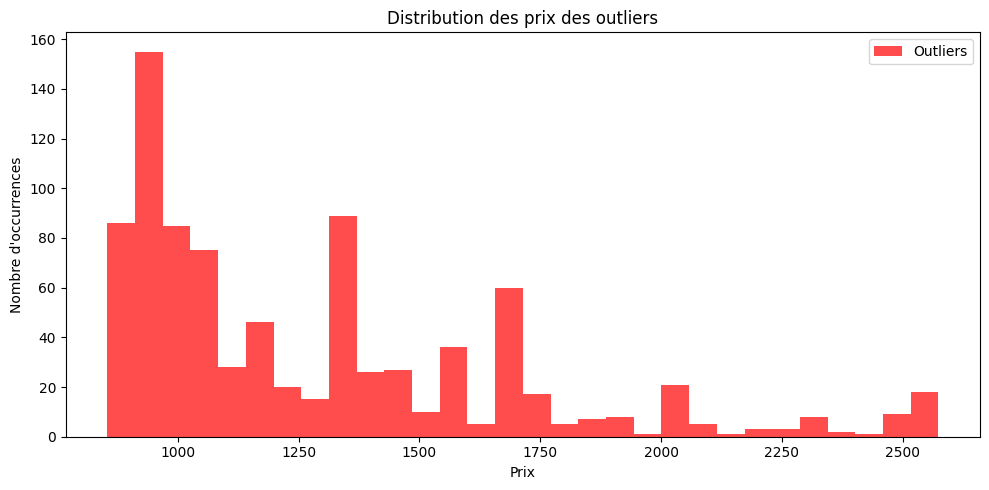

In [96]:
# Visualiser les outliers sur la colonne 'price'
plt.figure(figsize=(10, 5))
plt.hist(outliers['price'], bins=30, color='red', alpha=0.7, label='Outliers')
plt.xlabel('Prix')
plt.ylabel('Nombre d\'occurrences')
plt.title('Distribution des prix des outliers')
plt.legend()
plt.tight_layout()
plt.show()

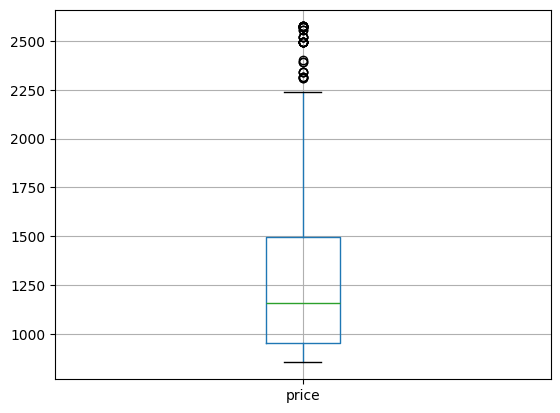

In [97]:
outliers[['price']].boxplot()
plt.show()

In [98]:
# Afficher les catégories de produits dont le prix est supérieur ou égal à 2500
categories_high_price = df[df['price'] >= 2500]['category_code'].unique()
print("Catégories de produits avec un prix >= 2500 :")
print(categories_high_price)

Catégories de produits avec un prix >= 2500 :
['electronics.clocks' 'sport.bicycle' None 'computers.desktop'
 'electronics.video.tv']
